/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_onsky/Experiment0000_iter1_Probe_0001_158_0001.fits
- Creating difference of images...
!!!! ACTION: MAXIMUM PSF HAS TO BE VERIFIED ON IMAGE:  [12556.11076522 16801.23426628 14956.01553469 13622.76301052
 14912.18939035 13590.92849915  7159.83675297  5009.03321985
  8182.53312206  8866.78302753  7541.20840505  3669.3280202 ]
No recentering
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
- Estimating the focal plane electric field...
/Users/apo

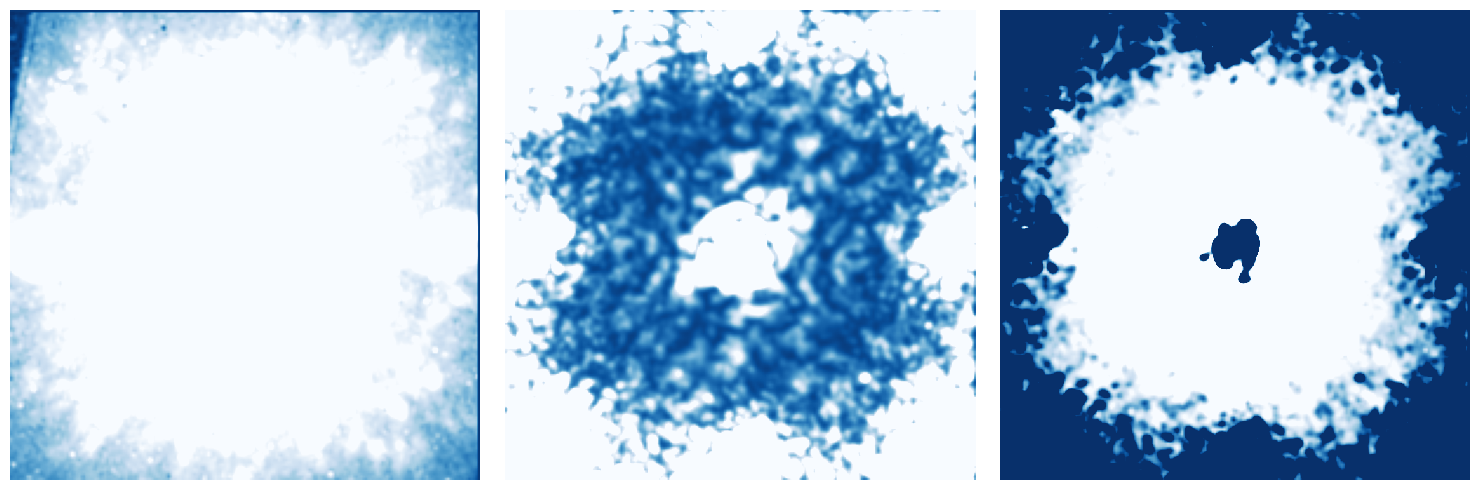

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

import Performance_function as perf
import sphere_efc.SPHERE_EFC_Func as SPHERE
from astropy.io import fits
from scipy.optimize import fmin_powell as fmin_powell
import glob
from natsort import natsorted

import importlib

importlib.reload(SPHERE)

import matplotlib as mpl

mpl.rcParams['image.origin'] = 'lower'


onsky=1 #Set 0 for internal pup ; 1 for an on sky correction
#Coronagraph that is used
coro='APLC'
#Dark hole size : param namemask in CreateMatrixfromModelEFConSPHERE.py
dhsize=1

gain=0 # Keep 0 for CDI postprocessing!!

#Algorithm for estimation. Should be either PWP or BTW
estim_algorithm='PWP'

#Number of probing actuator
zone_to_correct='FDH' #vertical #horizontal #FDH

#Type of probes used for PWP
probe_type='individual_act' #'sinc' #'individual_act'

#SizeProbes : can be 296, 400 or 500 (in nm)
size_probes=296

#Do you want to center your image at each iteration. Set 1 for yes, 0 for no.
centeringateachiter=0
#Do you want to rescale the coherent intensity to match the total intensity in the DH?
rescaling=0

# Path 
#WORK_PATH0='/Users/apoitier/Documents/Research/CDI/SPHERE/cdi-jun04-2024/'
WORK_PATH1='/Users/apoitier/Documents/Research/Softwares/sphere_efc/sphere_efc/'
MatrixDirectory= WORK_PATH1 + 'MatricesAndModel/IFS_OBS_H/'
ImageDirectory= '/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_onsky/'

exp_name = 'Experiment0000_'


centerx, centery = fits.getdata(ImageDirectory + exp_name + 'centerxy.fits')
which_nd = 'ND_2.0'

ModelDirectory = WORK_PATH1 + 'Model/'

if onsky == 0:
    lightsource_estim = 'InternalPupil_'
else:
    lightsource_estim = 'VLTPupil_'

lightsource_estim = lightsource_estim + coro + '_'


if coro == 'APLC':
    if zone_to_correct == 'vertical':
        posprobes = [678 , 679]#0.3cutestimation*squaremaxPSF*8/amplitude pour internal pup    #0.2*squaremaxPSF*8/amplitude pour on sky
    elif zone_to_correct == 'horizontal':
        posprobes = [893 , 934]
    elif zone_to_correct == 'FDH':
        posprobes = [678 , 679, 720]

    
elif coro == 'FQPM':
    if zone_to_correct == 'vertical':
        posprobes = [678 , 679]#0.3cutestimation*squaremaxPSF*8/amplitude pour internal pup    #0.2*squaremaxPSF*8/amplitude pour on sky
    elif zone_to_correct == 'horizontal':
        posprobes = [1089 , 1125] #FQPM
    elif zone_to_correct == 'FDH':
        raise ValueError('This setting is not available for FQPM yet')

param = {
  "ImageDirectory": ImageDirectory,
  "MatrixDirectory": MatrixDirectory,
  "exp_name": exp_name,
  "dhsize": dhsize,
  "zone_to_correct":zone_to_correct,
  "centerx": centerx,
  "centery": centery,
  "which_nd": which_nd,
  "onsky": onsky,
  "size_probes": size_probes,
  "amplitudeEFCMatrix": 8, #required for the code to run but useless
  "corr_mode": 1, #required for the code to run but useless
  "centeringateachiter": centeringateachiter,
  "dimimages": 200,
  "gain": gain,
  "rescaling": rescaling,
  "estim_algorithm": estim_algorithm,
  "probe_type": probe_type,

  "coro": coro,
  "live_matrix_measurement": False,
  "wave": 1.667e-6,
  "ModelDirectory": ModelDirectory,
  "lightsource_estim": lightsource_estim,
  "lightsource_corr": lightsource_estim, #required for the code to run but useless
  "posprobes": posprobes,
  "correction_channel": 1,
  "detector":"IFS", #Can be IRDIS or IFS
  "obs_band":"OBS_H" #Can also be 'OBS_YJ' or 'OBS_H3'

}


processed_directory = ImageDirectory + 'processed_data/'
if not os.path.exists(processed_directory):
        os.makedirs(processed_directory)

cube_co = []
cube_inco = []
cube_tot = []
PA = []

target_name = 'HD 135344'
estimated_onsky_PA_of_the_planet = 0
nbiter = 2
for file_raw in natsorted(glob.glob(ImageDirectory+exp_name+'iter*Probe_0001*.fits')):
    print(file_raw)
    param['nbiter'] = nbiter
    coherent_signal, incoherent_signal, imagecorrection, Images_to_display, pentespourcorrection  = SPHERE.resultEFC(param)
    cube_co.append(coherent_signal)
    cube_inco.append(incoherent_signal)
    cube_tot.append(imagecorrection)
    time_now = fits.getval(file_raw,'DATE-OBS')
    PA.append(perf.PA_on_detector(target_name, time_now, estimated_onsky_PA_of_the_planet, verbose=False))
    nbiter = nbiter + 1
    
cube_co = np.array(cube_co)
cube_inco = np.array(cube_inco)
cube_tot = np.array(cube_tot)
PA = 1 * np.array(PA)
    
fits.writeto(processed_directory+'signal_coh.fits',cube_co,overwrite=True)
fits.writeto(processed_directory+'signal_inc.fits',cube_inco,overwrite=True)
fits.writeto(processed_directory+'signal_tot.fits',cube_tot,overwrite=True)
fits.writeto(processed_directory+'PA.fits',-PA,overwrite=True)



which = 0
img1 = cube_tot[which,4]
img2 = cube_co[which,4]
img3 = cube_inco[which,4]
vmin = -0.5e-5
vmax = 1.5e-4
cmaps = 'Blues_r'

# Plotting the images side by side
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img1, vmin=vmin, vmax=vmax, cmap=cmaps)
axs[0].axis('off')  # Hide axes
#axs[0].set_title('Image 1')

axs[1].imshow(img2, vmin=vmin, vmax=vmax, cmap=cmaps)
axs[1].axis('off')
#axs[1].set_title('Image 2')

axs[2].imshow(img3, vmin=vmin, vmax=vmax, cmap=cmaps)
axs[2].axis('off')
#axs[2].set_title('Image 3')

plt.tight_layout()
#plt.savefig(processed_directory + '1iter_example.pdf')
plt.show()

In [ ]:
import Performance_function as perf
import sphere_efc.Definitions_for_matrices as matrices

#Filter unwanted images from the cube; remove corresponds to their index
#remove = []#np.append(np.arange(3,len(cube_co))[::-1],1)

#Create a mask to apply to each CDI and total intensity images. Can adjust the parameters. Was 10,65
mask = matrices.creatingMaskDH(200,'circle',choosepixDH=[-70, 70, 5, 70], circ_rad=[12, 65], circ_side="Full", circ_offset=0, circ_angle=0)

print('INCOHERENT COMPONENT')
cube_inco_removed = cube_inco.copy()[:,:]* mask

#Filter pixel with bad estimation. Can adjust the parameter
cube_inco_removed[np.where(np.abs(cube_inco_removed)>1e-2)]=0

#Removing worse images from the cube
newPA = PA.copy()
# for i in remove:
#     cube_inco_removed = np.delete(cube_inco_removed, i, axis = 0)
#     newPA = np.delete(newPA, i, axis = 0)

# ADI of cube inco
u,s,vh = perf.get_cube_svd(cube_inco_removed)
vector = np.arange(len(cube_inco_removed))
ADI_inco_result = perf.reduction_ADI(u, s, vh, vector, - newPA)
cube_inco_rotated = perf.rotate_cube(cube_inco_removed, - newPA)

#ADI_hide = remove_center_cube(ADI_result, 30)

# High-pass filtering of ADI[0] (where the cube has simply been rotated and stacked)
ADI_inco_filtered = []
for high_pass_filter_cut in np.arange(1,11):
    ADI_inco_filtered.append(perf.high_pass_filter(ADI_inco_result[0], high_pass_filter_cut))
ADI_inco_filtered = np.array(ADI_inco_filtered)
fits.writeto(processed_directory +'Rotated_stacked_hpfiltered_inc.fits', ADI_inco_filtered, overwrite=True)
fits.writeto(processed_directory +'Rotated_stacked_inc.fits', ADI_inco_result[0], overwrite=True)

#ADI_hide_and_filtered = remove_center_cube(ADI_filtered, 30)

fits.writeto(processed_directory +'ADI_inc.fits', ADI_inco_result, overwrite=True)
fits.writeto(processed_directory +'Rotated_inc.fits', cube_inco_rotated, overwrite=True)